<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-21-function-transformer-in-scikit-learn?scriptVersionId=340631036" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🤖 ML 21 — Function Transformer in Scikit-learn

### **Master FunctionTransformer for Custom Feature Transformations in Scikit-learn**

---

# 🚀 Introduction

In real-world datasets, features often don't follow an ideal distribution. Some variables may be heavily skewed, contain extreme values, or have relationships that are difficult for machine learning models to learn directly.

Scikit-learn's **FunctionTransformer** provides a simple and flexible way to apply **custom mathematical transformations** to your features while keeping them fully compatible with **Pipelines** and **ColumnTransformer**. Instead of manually transforming data before training, FunctionTransformer allows preprocessing to become part of your machine learning workflow, making your code cleaner, reusable, and less prone to data leakage.

In this notebook, you'll learn how to use FunctionTransformer to apply common mathematical transformations such as **Log Transformation**, **Reciprocal Transformation**, and **Square Root Transformation**, understand when each should be used, and see how they can improve feature distributions and model performance.



---

# 📖 What is FunctionTransformer?

**FunctionTransformer** is a preprocessing utility in **Scikit-learn** that allows you to apply **any custom Python function** to your dataset as part of a machine learning pipeline.

Instead of manually modifying your features before training a model, FunctionTransformer wraps the transformation into a reusable Scikit-learn transformer. This makes preprocessing consistent during both training and prediction.

It is especially useful when applying mathematical transformations like:

* 📈 Log Transformation
* 🔄 Reciprocal Transformation
* √ Square Root Transformation
* 📦 Cube Root Transformation
* ⚙️ Custom user-defined functions

---

# 🔍 Why Use FunctionTransformer?

Without FunctionTransformer:

* Transformations are performed manually.
* You may accidentally apply different preprocessing during inference.
* It becomes difficult to integrate preprocessing into Pipelines.

With FunctionTransformer:

* ✅ Keeps preprocessing inside the pipeline.
* ✅ Prevents data leakage.
* ✅ Makes code cleaner and reusable.
* ✅ Works seamlessly with Pipeline and ColumnTransformer.
* ✅ Supports any custom transformation function.

---

# 🎯 When Should You Use FunctionTransformer?

FunctionTransformer is useful when you need to:

* Transform skewed numerical features.
* Reduce the effect of outliers.
* Apply mathematical functions to improve feature distributions.
* Create custom preprocessing steps.
* Include feature transformations inside a machine learning pipeline.

---
# 📦 Import Libraries

Import all the required libraries for data manipulation, visualization, preprocessing, model building, and evaluation.

In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

---
# 📂 Load Dataset

Load the Titanic dataset and keep only the features required for demonstrating Function Transformer.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ahmedfakhar123/titanic-survival-dataset/Titanic_Survival_Dataset.csv",
                usecols=['Age','Fare','Survived'])
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


---
# 🧹 Data Preparation

Handle missing values and split the dataset into input features and target labels.

In [3]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [4]:
X = df.drop(columns=["Survived"])
y = df.Survived

---
# ✂️ Train-Test Split

Split the dataset into training and testing sets for unbiased model evaluation.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

---
# 📊 Feature Distribution Before Transformation

Let's examine the distribution of both numerical features before applying any transformations.

## 👤 Age Distribution

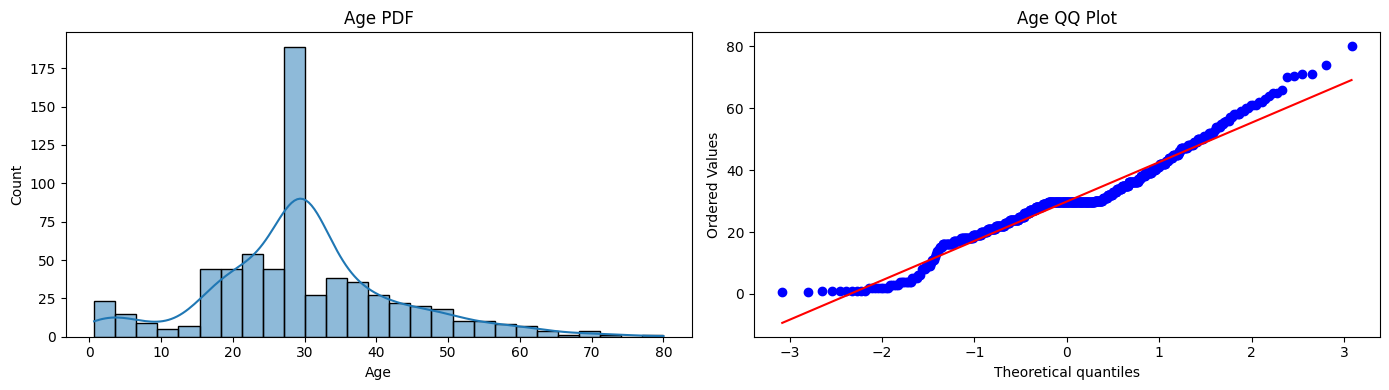

In [6]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.tight_layout()
plt.show()

## 💰 Fare Distribution

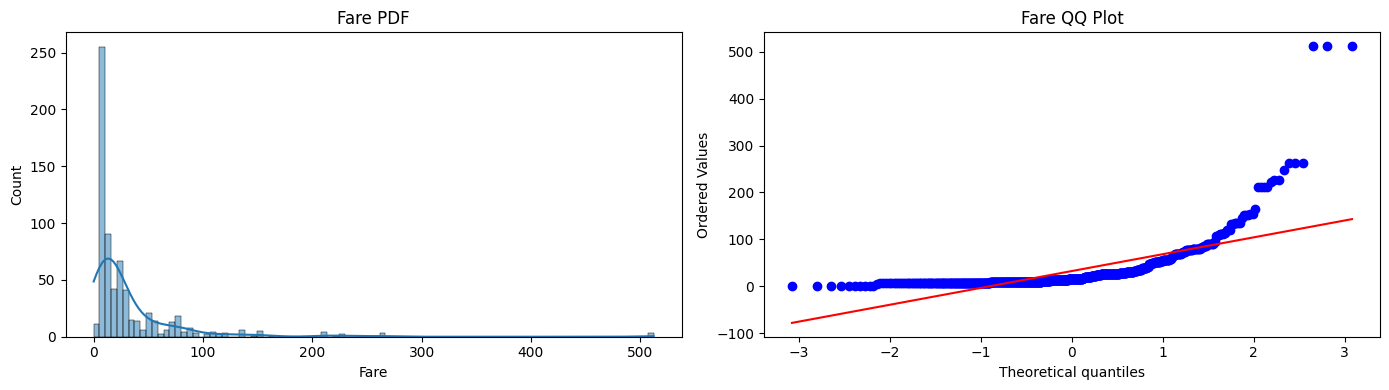

In [7]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.tight_layout()
plt.show()

---
# 🤖 Baseline Model Performance

Train Logistic Regression and Decision Tree models using the original features to establish baseline performance.

In [8]:
model1 = LogisticRegression()
model2 = DecisionTreeClassifier()

model1.fit(X_train, y_train)
model2.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)

print(f"Accuracy of LogisticRegression: {accuracy_score(y_test, y_pred1)}")
print(f"Accuracy of DecisionTreeClassifier: {accuracy_score(y_test, y_pred2)}")

Accuracy of LogisticRegression: 0.6860986547085202
Accuracy of DecisionTreeClassifier: 0.6771300448430493


---
# 🔄 Applying Log Transformation

Use FunctionTransformer with `np.log1p()` to reduce skewness and make feature distributions closer to normal.

In [9]:
trf = FunctionTransformer(func=np.log1p)

X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

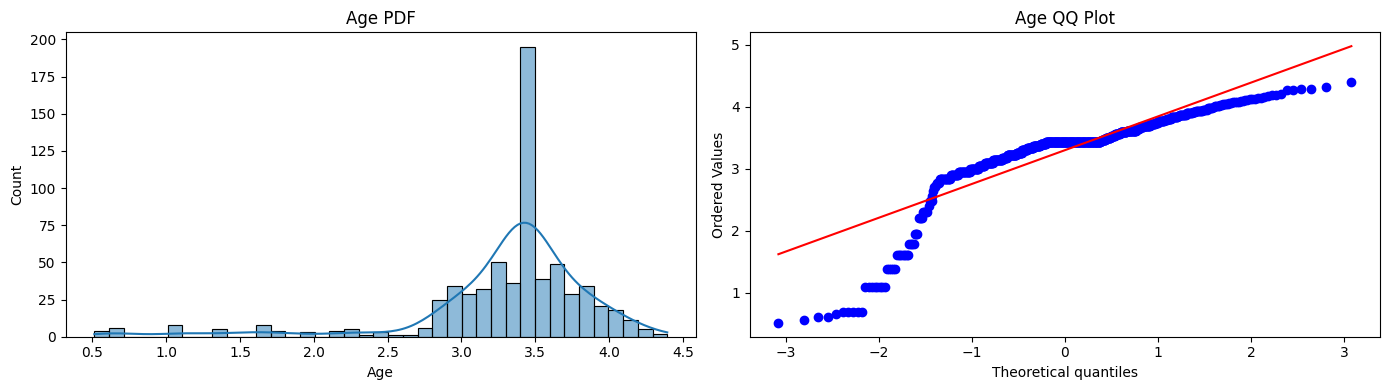

In [10]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train_transformed['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.tight_layout()
plt.show()

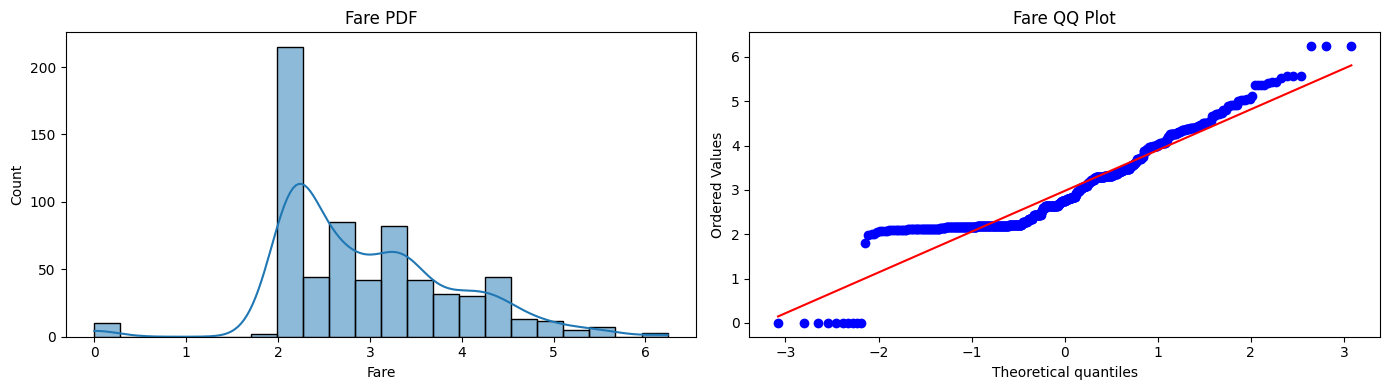

In [11]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train_transformed['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.tight_layout()
plt.show()

---
# 📊 Model Performance After Log Transformation

Evaluate whether the transformed features improve model performance.

In [12]:
model1 = LogisticRegression()
model2 = DecisionTreeClassifier()

model1.fit(X_train_transformed, y_train)
model2.fit(X_train_transformed, y_train)

y_pred_transformed1 = model1.predict(X_test_transformed)
y_pred_transformed2 = model2.predict(X_test_transformed)

print(f"Accuracy of LogisticRegression: {accuracy_score(y_test, y_pred_transformed1)}")
print(f"Accuracy of DecisionTreeClassifier: {accuracy_score(y_test, y_pred_transformed2)}")

Accuracy of LogisticRegression: 0.7130044843049327
Accuracy of DecisionTreeClassifier: 0.6636771300448431


---
# ⚙️ Applying Different Transformations to Multiple Features

Using ColumnTransformer, apply different mathematical transformations to different columns.

* **Fare → Log Transformation**
* **Age → Square Transformation**

In [13]:
trf2 = ColumnTransformer([
    ("log", FunctionTransformer(np.log1p), ["Fare"]),
    ("square", FunctionTransformer(np.square), ["Age"])],
    remainder='passthrough'
)

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.fit_transform(X_test)

---
# 📈 Model Performance with Multiple Transformations

Train the models again and compare the results after applying multiple feature transformations.

In [14]:
model1 = LogisticRegression()
model2 = DecisionTreeClassifier()

model1.fit(X_train_transformed2, y_train)
model2.fit(X_train_transformed2, y_train)

y_pred_transformed1 = model1.predict(X_test_transformed2)
y_pred_transformed2 = model2.predict(X_test_transformed2)

print(f"Accuracy of LogisticRegression: {accuracy_score(y_test, y_pred_transformed1)}")
print(f"Accuracy of DecisionTreeClassifier: {accuracy_score(y_test, y_pred_transformed2)}")

Accuracy of LogisticRegression: 0.6771300448430493
Accuracy of DecisionTreeClassifier: 0.6771300448430493


---
# ✅ Cross-Validation Evaluation

Instead of relying on a single train-test split, evaluate the transformed dataset using 10-Fold Cross Validation for a more reliable performance estimate

In [15]:
X_transformed2 = trf2.fit_transform(X)

model1 = LogisticRegression()
model2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(model1 ,X_transformed2, y,scoring='accuracy', cv=10)))
print("DT",np.mean(cross_val_score(model2, X_transformed2, y,scoring='accuracy', cv=10)))

LR 0.653258426966292
DT 0.6588514357053683


---
# 🧪 Comparing Different Mathematical Transformations

Create a reusable function to quickly evaluate different mathematical transformations on the Fare feature.

The function:

* Applies the selected transformation
* Performs 10-Fold Cross Validation
* Reports model accuracy
* Visualizes the distribution before and after transformation

In [16]:
def apply_transform(transform):
    X = df.drop(columns=["Survived"])
    y = df.Survived
    
    trf = ColumnTransformer([(f'{transform}', FunctionTransformer(transform), ['Fare'])],
                            remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    model = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(model, X_trans, y, scoring='accuracy', cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:, 0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()
    print(X_trans)

---
# ▶️ Example: Applying Sine Transformation

Apply the Sine Transformation to observe how it changes the feature distribution and affects model performance

Accuracy 0.6195131086142323


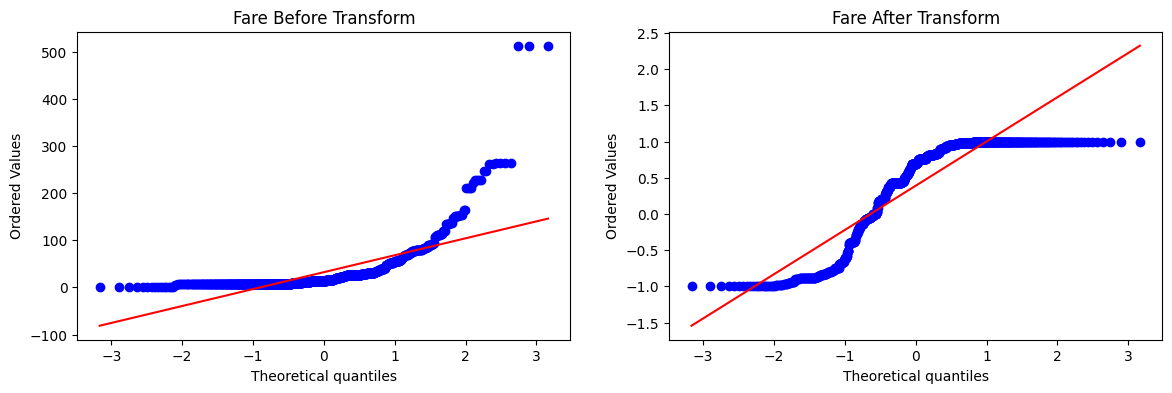

[[ 0.82308088 22.        ]
 [ 0.82676416 38.        ]
 [ 0.99747926 26.        ]
 ...
 [-0.99374071 29.69911765]
 [-0.98803162 26.        ]
 [ 0.99459878 32.        ]]


In [17]:
apply_transform(np.sin)

---

# 🎯 Conclusion

In this notebook, we explored how **FunctionTransformer** can apply custom mathematical transformations with just a few lines of code. We compared model performance before and after transformation, applied different transformations to multiple columns using **ColumnTransformer**, and evaluated the results using **Cross Validation**.

This workflow demonstrates that selecting an appropriate transformation can improve feature distributions and, in some cases, boost the performance of Machine Learning models. 🚀

---

# 🔜 What's Next?

[**🤖 ML 22 — Power Transformer in Scikit-learn**](http://https://www.kaggle.com/code/ahmedfakhar123/ml-22-power-transformer-in-scikit-learn)

In the **next notebook**, we'll take feature transformation a step further with **PowerTransformer**. Instead of manually choosing a transformation, PowerTransformer automatically finds the optimal transformation using **Box-Cox** and **Yeo-Johnson** methods to reduce skewness, stabilize variance, and make features more closely follow a normal distribution.

Stay tuned for **🤖 ML 22 — Power Transformer in Scikit-learn** where we'll compare these techniques and see how they impact Machine Learning models. 🚀
